# Dataset Analysis using Word2Vec

This notebook analyses the dataset and trains a **Word2Vec** model to explore semantic relationships between the words.

Main goals:
- Load cleaned datasets from `processed_data/`
- Inspect title and combined_text lengths
- Analyse frequent words
- Train a Word2Vec model on cleaned Arabic text
- Explore similar words
- Visualise word embeddings using PCA and t-SNE

In [47]:
from pathlib import Path
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from gensim.models import Word2Vec


from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


## 1. Load Cleaned Dataset Files

This cell searches for cleaned CSV files inside `processed_data/`. If your files are saved somewhere else, change `PROCESSED_DATA_DIR`.

In [48]:
PROCESSED_DATA_DIR = Path("./data/processed")

csv_files = sorted(PROCESSED_DATA_DIR.rglob("*.json"))

print(f"Found {len(csv_files)} CSV files")
for i, file in enumerate(csv_files):
    print(f"{i}: {file}")


Found 1 CSV files
0: data\processed\corpus_clean.json


## 2. Combine Cleaned Files

In [33]:
dataframes = []

for file in csv_files:
    temp_df = pd.read_json(file)
    temp_df["source_file"] = file.stem
    print( temp_df["source_file"].unique())

    if "split" not in temp_df.columns:
        temp_df["split"] = file.stem

    dataframes.append(temp_df)

if len(dataframes) == 0:
    raise FileNotFoundError("No CSV files found. Make sure processed_data/ contains cleaned CSV files.")

df = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


['corpus_clean']
Combined dataset shape: (500, 10)
Columns: ['doc_id', 'title', 'url', 'topic', 'clean_title', 'clean_summary', 'clean_content', 'combined_text', 'source_file', 'split']


,doc_id,title,url,topic,clean_title,clean_summary,clean_content,combined_text,source_file,split
0,0,Playing a 2D Game Indefinitely using NEAT and ...,http://arxiv.org/abs/2207.14140v1,Game engine architecture,playing a 2d game indefinitely using neat and ...,for over a decade now robotics and the use of ...,for over a decade now robotics and the use of ...,playing a 2d game indefinitely using neat and ...,corpus_clean,corpus_clean
1,1,Optimal strategies for a game on amenable semi...,http://arxiv.org/abs/1104.3098v3,Game engine architecture,optimal strategies for a game on amenable semi...,the semigroup game is a twoperson zerosum game...,the semigroup game is a twoperson zerosum game...,optimal strategies for a game on amenable semi...,corpus_clean,corpus_clean
2,2,Dynamic Structure in Four-strategy Game: Theor...,http://arxiv.org/abs/2203.14669v1,Game engine architecture,dynamic structure in fourstrategy game theory ...,game dynamics theory as a field of science the...,game dynamics theory as a field of science the...,dynamic structure in fourstrategy game theory ...,corpus_clean,corpus_clean
3,3,Advanced Drone Swarm Security by Using Blockch...,http://arxiv.org/abs/2112.15454v4,Game engine architecture,advanced drone swarm security by using blockch...,this research contributes to the security desi...,this research contributes to the security desi...,advanced drone swarm security by using blockch...,corpus_clean,corpus_clean
4,4,Architectural Implications of Graph Neural Net...,http://arxiv.org/abs/2009.00804v2,Game engine architecture,architectural implications of graph neural net...,graph neural networks gnn represent an emergin...,graph neural networks gnn represent an emergin...,architectural implications of graph neural net...,corpus_clean,corpus_clean


## 3. Validate Required Columns

In [34]:
required_columns = ["clean_title", "combined_text"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}. Please check preprocessing output.")

df = df.dropna(subset=["clean_title", "combined_text"]).copy()
df = df[
    (df["clean_title"].astype(str).str.strip() != "") &
    (df["combined_text"].astype(str).str.strip() != "")
].copy()

print("Dataset shape after validation:", df.shape)


Dataset shape after validation: (500, 10)


## 4. Basic Dataset Overview

In [35]:
print("Number of samples:", len(df))

if "split" in df.columns:
    print("\nSamples by split:")
    display(df["split"].value_counts().to_frame("count"))

if "source_file" in df.columns:
    print("\nSamples by source file:")
    display(df["source_file"].value_counts().to_frame("count"))


Number of samples: 500

Samples by split:


,count
split,
corpus_clean,500



Samples by source file:


,count
source_file,
corpus_clean,500


## 5. Tokenisation for Analysis

In [36]:
def tokenize_text(text):
    return str(text).split()

df["title_tokens"] = df["clean_title"].apply(tokenize_text)
df["combined_text_tokens"] = df["combined_text"].apply(tokenize_text)

df["title_len"] = df["title_tokens"].apply(len)
df["combined_text_len"] = df["combined_text_tokens"].apply(len)

display(df[["clean_title", "combined_text", "title_len", "combined_text_len"]].head())


,clean_title,combined_text,title_len,combined_text_len
0,playing a 2d game indefinitely using neat and ...,playing a 2d game indefinitely using neat and ...,10,495
1,optimal strategies for a game on amenable semi...,optimal strategies for a game on amenable semi...,8,336
2,dynamic structure in fourstrategy game theory ...,dynamic structure in fourstrategy game theory ...,8,315
3,advanced drone swarm security by using blockch...,advanced drone swarm security by using blockch...,9,356
4,architectural implications of graph neural net...,architectural implications of graph neural net...,6,318


## 6. Length Statistics

In [37]:
print("title length statistics:")
display(df["title_len"].describe().to_frame().T)

print("combined_text length statistics:")
display(df["combined_text_len"].describe().to_frame().T)


title length statistics:


,count,mean,std,min,25%,50%,75%,max
title_len,500.0,7.178,4.144958,1.0,3.0,7.0,10.0,22.0


combined_text length statistics:


,count,mean,std,min,25%,50%,75%,max
combined_text_len,500.0,916.318,1551.977839,53.0,329.75,393.0,623.5,13755.0


## 7. Length Distributions

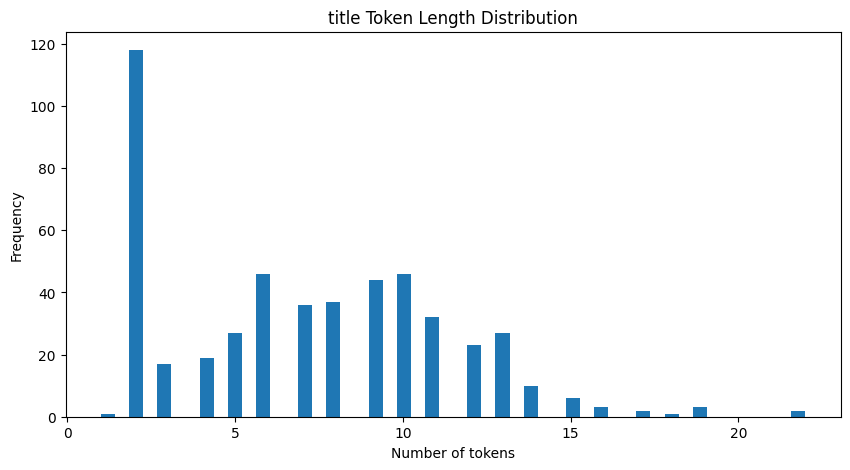

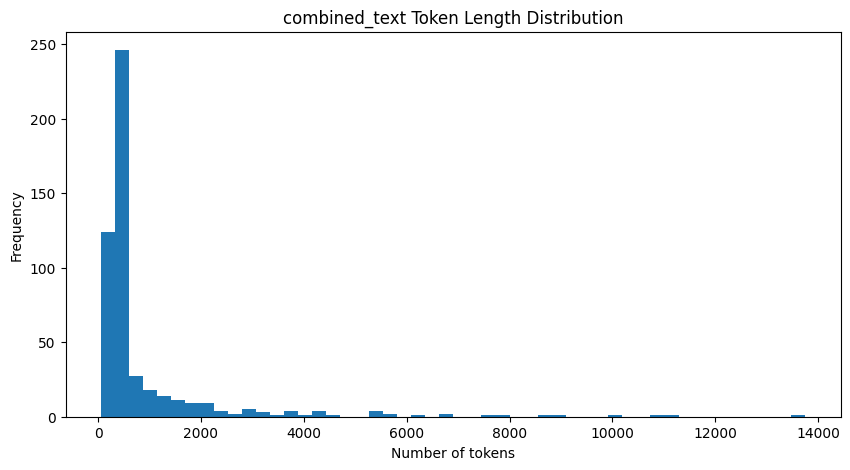

In [38]:
plt.figure(figsize=(10, 5))
plt.hist(df["title_len"], bins=50)
plt.title("title Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(df["combined_text_len"], bins=50)
plt.title("combined_text Token Length Distribution")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()


## 8. Most Frequent Words

In [39]:
all_title_tokens = [token for tokens in df["title_tokens"] for token in tokens]
all_combined_text_tokens = [token for tokens in df["combined_text_tokens"] for token in tokens]

title_word_counts = Counter(all_title_tokens)
combined_text_word_counts = Counter(all_combined_text_tokens)

title_freq_df = pd.DataFrame(title_word_counts.most_common(30), columns=["word", "frequency"])
combined_text_freq_df = pd.DataFrame(combined_text_word_counts.most_common(30), columns=["word", "frequency"])

print("Top title words:")
display(title_freq_df)

print("Top combined_text words:")
display(combined_text_freq_df)


Top title words:


,word,frequency
0,and,125
1,for,106
2,of,103
3,readme,102
4,in,94
5,the,82
6,a,66
7,iot,49
8,security,46
9,content,40


Top combined_text words:


,word,frequency
0,the,22467
1,and,14862
2,of,12731
3,to,12114
4,a,8885
5,in,8455
6,for,5814
7,is,4865
8,that,3798
9,on,3461


## 9. Prepare Sentences for Word2Vec

In [40]:
word2vec_sentences = df["title_tokens"].tolist() + df["combined_text_tokens"].tolist()
word2vec_sentences = [tokens for tokens in word2vec_sentences if len(tokens) >= 3]

print("Number of sentences used for Word2Vec:", len(word2vec_sentences))
print("Example sentence tokens:")
print(word2vec_sentences[0][:30])


Number of sentences used for Word2Vec: 881
Example sentence tokens:
['playing', 'a', '2d', 'game', 'indefinitely', 'using', 'neat', 'and', 'reinforcement', 'learning']


## 10. Train Word2Vec Model

Important parameters:
- `vector_size`: embedding dimension
- `window`: context window size
- `min_count`: ignores rare words
- `sg=1`: Skip-gram model
- `sg=0`: CBOW model

In [41]:
word2vec_model = Word2Vec(
    sentences=word2vec_sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

print("Vocabulary size:", len(word2vec_model.wv))


Vocabulary size: 11846


## 11. Word Similarity Function

In [42]:
def show_similar_words(word, topn=10):
    if word not in word2vec_model.wv:
        print(f"'{word}' not found in vocabulary.")
        return None

    results = word2vec_model.wv.most_similar(word, topn=topn)
    result_df = pd.DataFrame(results, columns=["word", "similarity"])
    display(result_df)
    return result_df


## 12. Visualise Word Embeddings with PCA

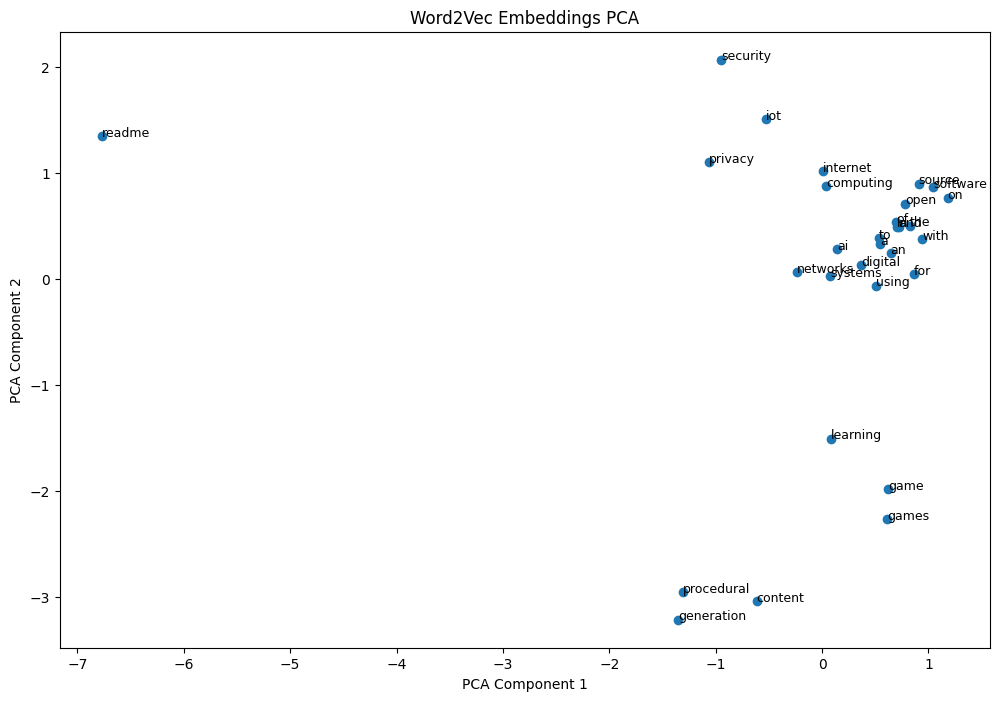

In [43]:
def plot_embeddings_pca(model, words, title="Word2Vec Embeddings PCA"):
    valid_words = [word for word in words if word in model.wv]

    if len(valid_words) < 2:
        print("Not enough valid words to plot.")
        return

    vectors = np.array([model.wv[word] for word in valid_words])
    pca = PCA(n_components=2, random_state=42)
    reduced_vectors = pca.fit_transform(vectors)

    plt.figure(figsize=(12, 8))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), fontsize=9)

    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

most_common_words = title_freq_df["word"].head(40).tolist()
plot_embeddings_pca(word2vec_model, most_common_words)


## 15. Visualise Word Embeddings with t-SNE

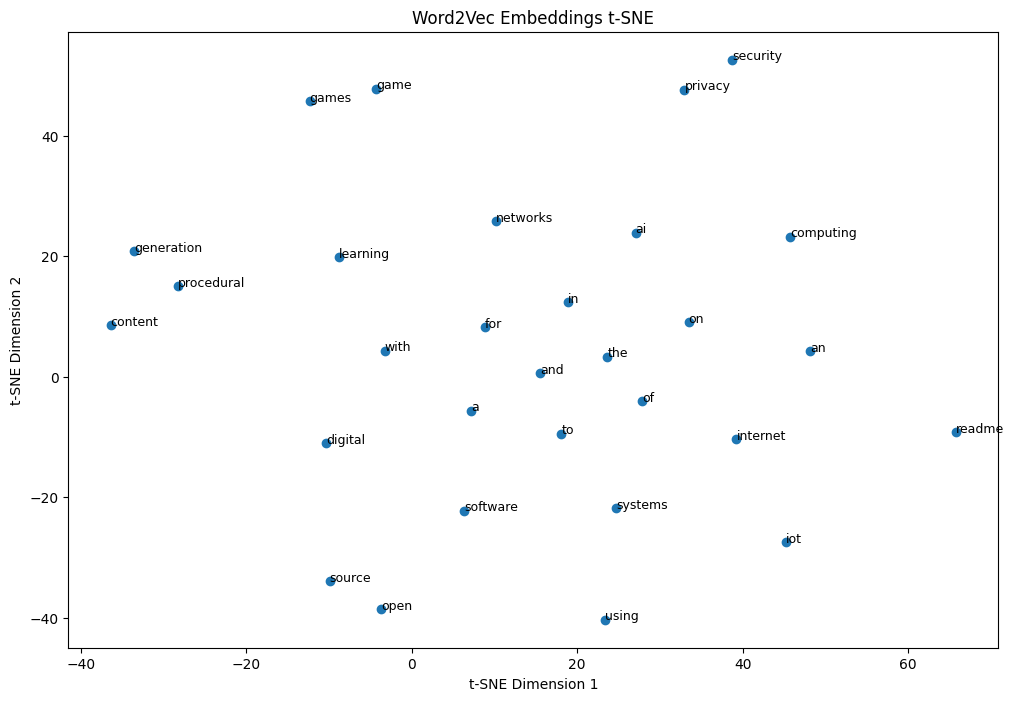

In [44]:
def plot_embeddings_tsne(model, words, title="Word2Vec Embeddings t-SNE"):
    valid_words = [word for word in words if word in model.wv]

    if len(valid_words) < 5:
        print("Not enough valid words to plot.")
        return

    vectors = np.array([model.wv[word] for word in valid_words])
    perplexity = min(10, len(valid_words) - 1)

    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca",
        learning_rate="auto"
    )
    reduced_vectors = tsne.fit_transform(vectors)

    plt.figure(figsize=(12, 8))
    plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1])

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), fontsize=9)

    plt.title(title)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

plot_embeddings_tsne(word2vec_model, most_common_words)


## 16. Save Word2Vec Model

In [45]:
MODEL_DIR = Path("./results/word2vec")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "arabic_word2vec.model"
word_vectors_path = MODEL_DIR / "arabic_word_vectors.kv"

word2vec_model.save(str(model_path))
word2vec_model.wv.save(str(word_vectors_path))

print("Saved Word2Vec model to:", model_path.resolve())
print("Saved word vectors to:", word_vectors_path.resolve())


Saved Word2Vec model to: C:\Users\moham\Desktop\IR_Project_Code\results\word2vec\arabic_word2vec.model
Saved word vectors to: C:\Users\moham\Desktop\IR_Project_Code\results\word2vec\arabic_word_vectors.kv


## 17. Save Analysis Tables

In [46]:
ANALYSIS_DIR = Path("./results/dataset_analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

title_freq_df.to_csv(ANALYSIS_DIR / "top_title_words.csv", index=False, encoding="utf-8-sig")
combined_text_freq_df.to_csv(ANALYSIS_DIR / "top_combined_text_words.csv", index=False, encoding="utf-8-sig")

cols_to_save = [col for col in ["split", "source_file", "title_len", "combined_text_len"] if col in df.columns]
df[cols_to_save].to_csv(
    ANALYSIS_DIR / "length_statistics_by_sample.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved analysis outputs to:", ANALYSIS_DIR.resolve())


Saved analysis outputs to: C:\Users\moham\Desktop\IR_Project_Code\results\dataset_analysis
